# Baseball Practice Session 2

In today's practice session, you'll practice:

1. Understanding statistics, percentiles, and good/bad player performances
2. Visualizing distributions and their shapes with boxplots and histograms
3. Comparing players using descriptive statistics and graphs

## Load player and batting data

In [109]:
import YData_baseball

YData_baseball.download_data("Lahman_2024u/Batting.csv")
YData_baseball.download_data("Lahman_2024u/People.csv")

The file `Batting.csv` already exists.
If you would like to download a new copy of the file, please rename the existing copy of the file.
The file `People.csv` already exists.
If you would like to download a new copy of the file, please rename the existing copy of the file.


In [110]:
import pandas as pd
import numpy as np

batting = pd.read_csv("Batting.csv")
players = pd.read_csv("People.csv")

batting.head(5)

,playerID,yearID,stint,teamID,lgID,G,G_batting,AB,R,H,...,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP,G_old
0,aardsda01,2004,1,SFN,NL,11,NaN,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,aardsda01,2006,1,CHN,NL,45,NaN,2,0,0,...,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,0.0,NaN
2,aardsda01,2007,1,CHA,AL,25,NaN,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,aardsda01,2008,1,BOS,AL,47,NaN,1,0,0,...,0.0,0.0,0,1.0,0.0,0.0,0.0,0.0,0.0,NaN
4,aardsda01,2009,1,SEA,AL,73,NaN,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


# 1. Descriptive Statistics

## 1.1. Calculating Mean and Median with Numpy

Using the batting data and the numpy package, calculate the mean and median hits (H) and walks (BB) for each season from 1871 to 2024. Note the relevant functions are `np.mean()` and `np.median()`.

In [111]:
# Hits
print(np.mean(batting["H"]))
print(np.median(batting["H"]))

33.89991883820436
7.0


In [112]:
# Walks
print(np.mean(batting["BB"]))
print(np.median(batting["BB"]))

11.964257290771982
2.0


## 1.2 Calculating Q1 and Q3

Quantitative data is often separated into quartiles, which each correspond to roughly 25% of the data. The main values are Q1 = 25% of the data, median = 50% of the data, and Q3 = 75% of the data. Using the `.quantile()` function, calculate Q1 and Q3 for the Stolen Bases column. Note that you will need to enter 25 and 75 into the function for Q1 and Q3, respectively. Also, you may need to use the `.dropna()` function on the data to remove missing values.

In [113]:
Q1 = batting["SB"].dropna().quantile(0.25)
Q3 = batting["SB"].dropna().quantile(0.75)

print("Q1 =", Q1)
print("Q3 =", Q3)

Q1 = 0.0
Q3 = 2.0


# 2. Percentiles and Player Comparison

## 2.1 Percentile Practice

Percentiles refer specifically to the percent of observations that are less than a certain value. Use the `.quantile()` function, and calculate the 90th percentile for hits (H) and walks (BB) for the 2024 season. How do these numbers compare to the mean and median that you computed previously?

In [114]:
batting_2024 = batting[batting["yearID"] == 2024]

hits_90 = batting_2024["H"].quantile(0.9)
walks_90 = batting_2024["BB"].quantile(0.9)

print("90th Percentile Hits =", hits_90)
print("90th Percentile Walks =", walks_90)

90th Percentile Hits = 94.0
90th Percentile Walks = 35.0


## 2.2 Comparing Judge and Ohtani

Aaron Judge and Shohei Ohtani are widely regarded as two of the best hitters in Major League Baseball. Using data from the 2024 MLB season, how do they compare to the rest of the league in terms of number of hits?

Specifically, calculate Aaron Judge’s and Shohei Ohtani’s percentile rank for hits among all MLB players in 2024.

Aaron Judge: playerID = "judgeaa01"

Shohei Ohtani: playerID = "ohtansh01"

In [115]:
# Extract hit totals
hits = batting_2024["H"].values 

# Player IDs
judge_id = "judgeaa01"
ohtani_id = "ohtansh01"

# Get individual hit totals
judge_hits = batting_2024.loc[batting_2024["playerID"] == judge_id, "H"].iloc[0]
ohtani_hits = batting_2024.loc[batting_2024["playerID"] == ohtani_id, "H"].iloc[0]

# Compute percentiles
judge_percentile = 100 * np.mean(hits <= judge_hits)
ohtani_percentile = 100 * np.mean(hits <= ohtani_hits)

print("Judge Percentile =", judge_percentile)
print("Ohtani Percentile =", ohtani_percentile)


Judge Percentile = 99.6365838885524
Ohtani Percentile = 99.87886129618413


## 3. Creating Histograms and Boxplots

## 3.1 Creating Histograms with Matplotlib

Histograms help us visualize a single quantitative variable. Use the Matplotlib package to create a histogram showing the distribution of hits during the 2024 season. The relevant function is called `hist()`. Write 1-2 issues with this plot. How might we fix them?

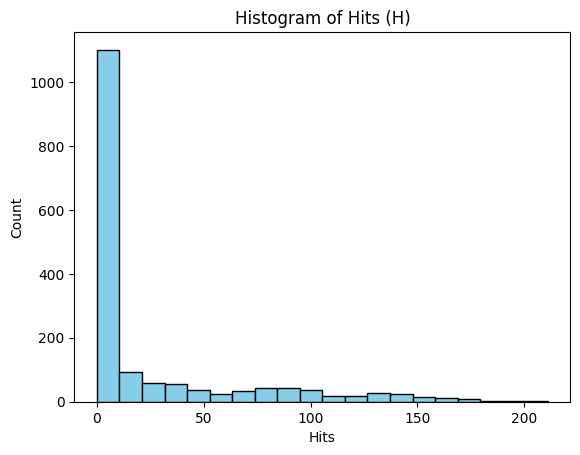

In [116]:
import matplotlib.pyplot as plt

plt.hist(batting_2024["H"], bins=20, color="skyblue", edgecolor="black")
plt.title("Histogram of Hits (H)")
plt.xlabel("Hits")
plt.ylabel("Count")
plt.show()

## 3.2 Modifying the Histogram

One solution to better visualize the data is to look at players with at least 25 hits. Filter the data to select these players, then recreate the histogram.

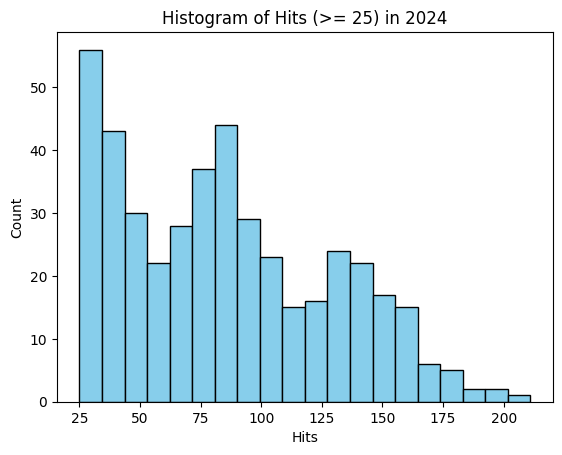

In [117]:
batting_2024_adjusted = batting_2024[batting_2024["H"] >= 25]

plt.hist(batting_2024_adjusted["H"], bins=20, color="skyblue", edgecolor="black")
plt.title("Histogram of Hits (>= 25) in 2024")
plt.xlabel("Hits")
plt.ylabel("Count")
plt.show()

## 3.3 Creating Histograms with Seaborn

Another package for creating visualizations is Seaborn. One function for making histograms is called `displot()`. Use this function to create another visualization for number of hits, and again select players with at least 25 hits.

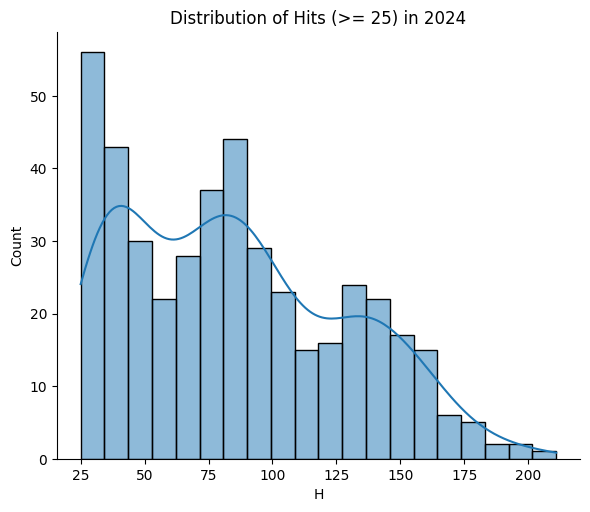

In [118]:
import seaborn as sns

sns.displot(
    data=batting_2024_adjusted,
    x="H",
    bins=20,
    kde=True,
    height=5,
    aspect=1.2
)
plt.title("Distribution of Hits (>= 25) in 2024")
plt.show()

## 3.4 Creating Boxplots with Matplotlib

Besides histograms, another way to visualize a single quantitative variable is with boxplots. These figures simply show the 5-number summary (minimum, Q1, median, Q3, maximum) for the data. We can create a boxplot using the `boxplot()` function. Let's use it to visualize hits for 2024 (for players with at least 25), and compare the plot to the histograms you just made.


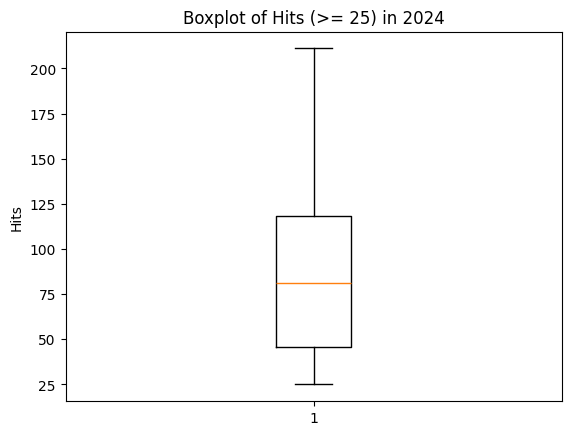

In [119]:
plt.boxplot(batting_2024_adjusted["H"])
plt.title("Boxplot of Hits (>= 25) in 2024")
plt.ylabel("Hits")
plt.show()

## 3.5 Creating Boxplots with Seaborn

Seaborn also allows us to create boxplots. Repeat the same visualization as above using the `catplot()` function.

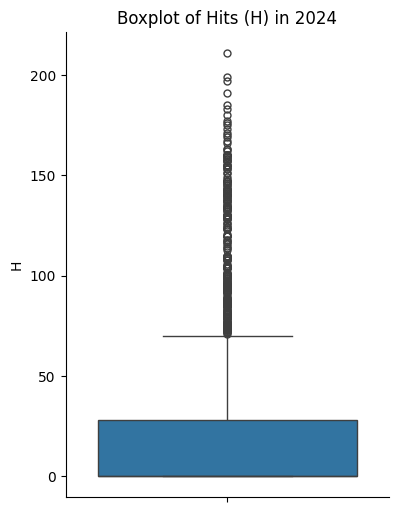

In [120]:
sns.catplot(
    data=batting_2024,
    y="H",
    kind="box",
    height=5,
    aspect=0.8
)
plt.title("Boxplot of Hits (H) in 2024")
plt.show()

## 4. Comparing 2024 MVP Candidates with Z-Scores

The 2024 season had stellar candidates for the MVP award. In the National League, the candidates were Aaron Judge (New York Yankees) – Winner, Juan Soto (New York Yankees), and Bobby Witt Jr. (Kansas City Royals). And in the American League, the candidates were Shohei Ohtani (Los Angeles Dodgers) – Winner, Francisco Lindor (New York Mets), and Ketel Marte (Arizona Diamondbacks).

## 4.1 Filtering Players

Filter the data to only include players with at least 100 plate appearances. This will help us remove noisy data points.

In [121]:
# Filter to players with meaningful playing time
batting_2024_100 = batting_2024[batting_2024["AB"] >= 100].copy()

# Compute mean and SD of home runs
hr_mean = batting_2024_100["HR"].mean()
hr_sd = batting_2024_100["HR"].std(ddof=0)

## 4.2 Computing Z-Scores

Compute each player's Z-score for home runs. Sort the data using the `sort_values()` function and show the top 20 players based on Z-scores.

In [122]:
# Compute HR z-score
hr_mean = batting_2024_100["HR"].mean()
hr_sd = batting_2024_100["HR"].std(ddof=0)

batting_2024_100.loc[:, "HR_z"] = (
    batting_2024_100["HR"] - hr_mean
) / hr_sd

# Merge names 
batting_2024_100 = batting_2024_100.merge(
    players,
    on="playerID",
    how="left"
)

# Final output
batting_2024_100.sort_values("HR_z", ascending=False).head(20)[
    ["nameFirst", "nameLast", "HR", "HR_z"]
]

,nameFirst,nameLast,HR,HR_z
197,Aaron,Judge,58,5.052190
293,Shohei,Ohtani,54,4.617295
352,Anthony,Santander,44,3.530057
378,Juan,Soto,41,3.203886
344,Brent,Rooker,39,2.986439
323,Jose,Ramirez,39,2.986439
299,Marcell,Ozuna,39,2.986439
359,Kyle,Schwarber,38,2.877715
172,Gunnar,Henderson,37,2.768991
240,Ketel,Marte,36,2.660267


## 4.3 Player Comparison

Comment on the players that are in the top 20.

In [123]:
%%capture

# You can run this code to covert this Jupyter notebook into a pdf
!quarto render practice_02_answers.ipynb --cache-refresh --to pdf 